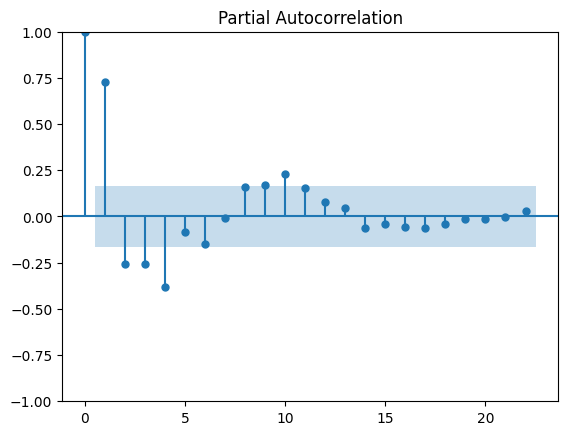

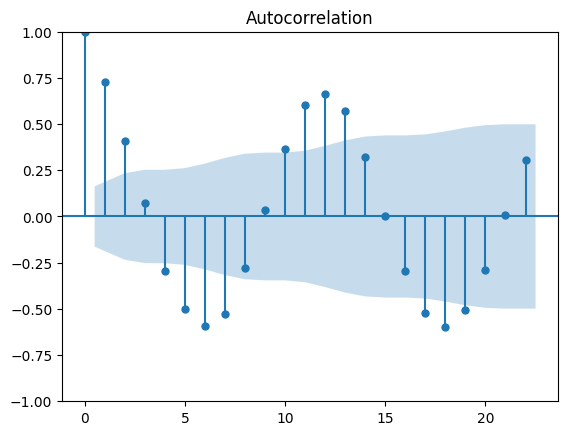

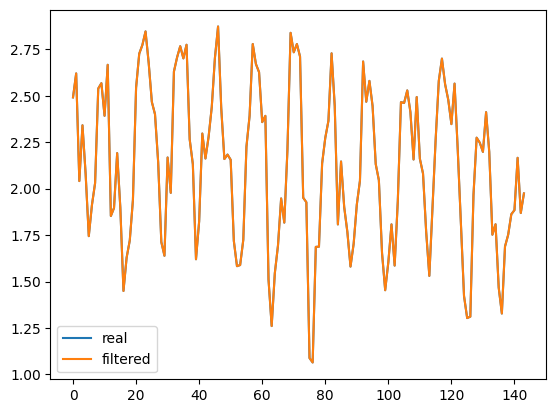

Serie: windspeedrecife.txt is_stationary False lags: 12 linhas: 104
****************************************************************************************************


,count,mean,std,min,25%,50%,75%,max,train_size,test_size,val_size
0,144.0,2.119913,0.426137,1.064516,1.79759,2.156224,2.465833,2.872864,116,0,28


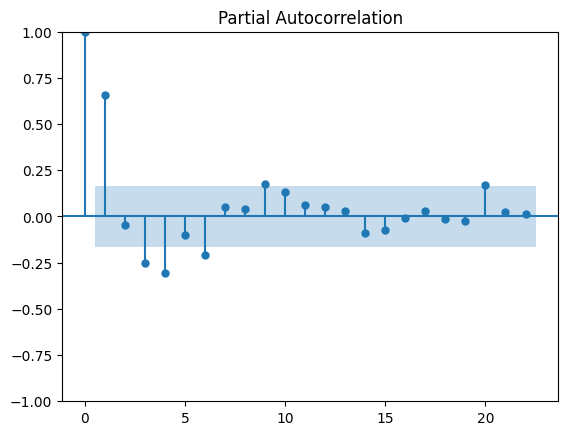

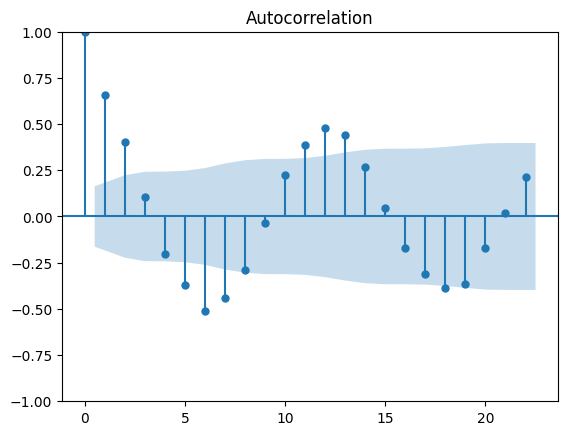

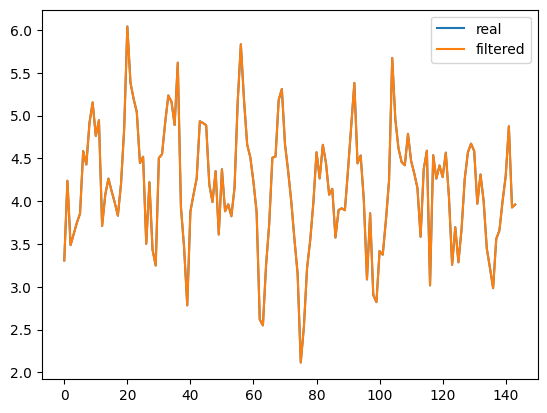

Serie: windspeednatal.txt is_stationary False lags: 12 linhas: 104
****************************************************************************************************


,count,mean,std,min,25%,50%,75%,max,train_size,test_size,val_size
0,144.0,4.16658,0.702643,2.116667,3.731021,4.222921,4.57457,6.04,116,0,28


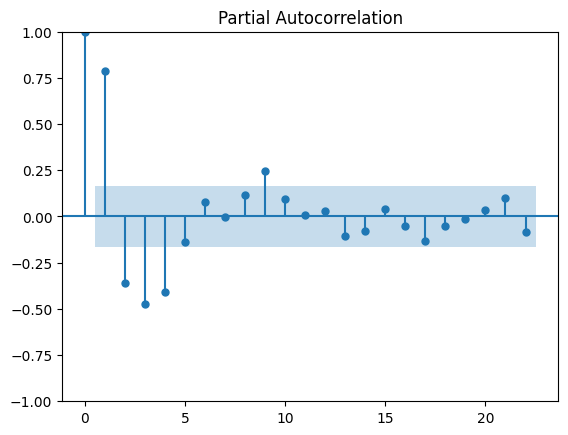

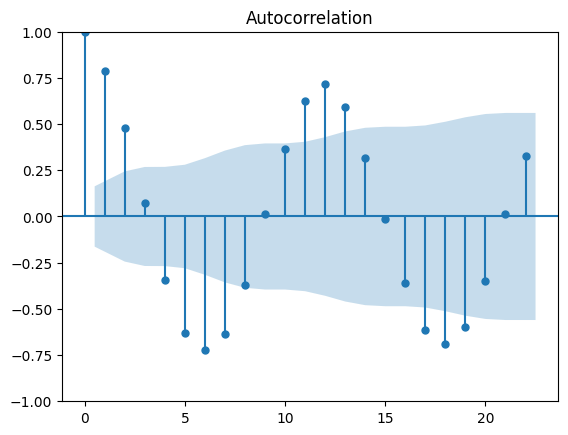

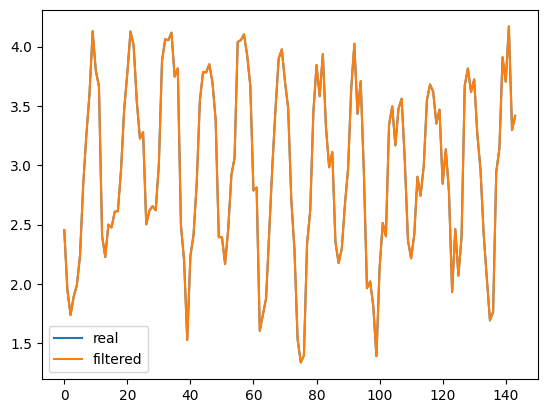

Serie: windspeedfortaleza.txt is_stationary False lags: 12 linhas: 104
****************************************************************************************************


,count,mean,std,min,25%,50%,75%,max,train_size,test_size,val_size
0,144.0,2.965821,0.74556,1.337778,2.400538,2.975269,3.626075,4.169893,116,0,28


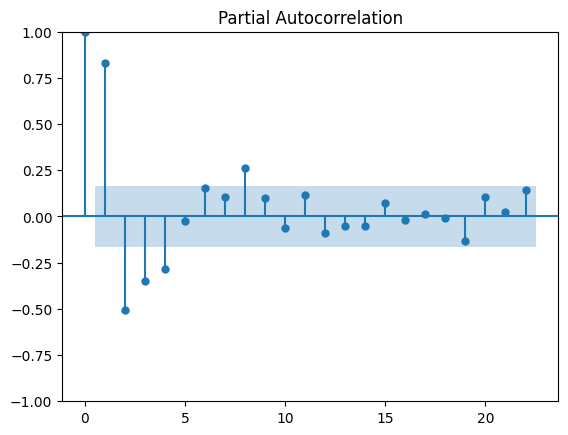

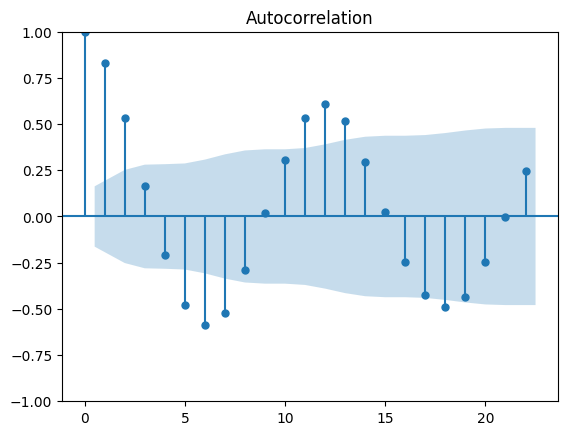

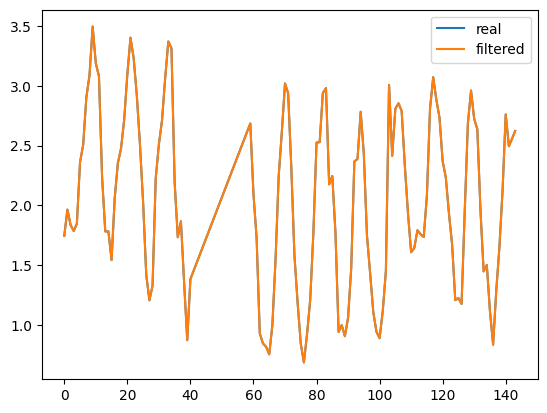

Serie: windspeedsaoluis.txt is_stationary False lags: 12 linhas: 104
****************************************************************************************************


,count,mean,std,min,25%,50%,75%,max,train_size,test_size,val_size
0,144.0,2.036972,0.700097,0.684946,1.514644,2.042519,2.570625,3.495833,116,0,28


In [1]:
from input import input
import config
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

%load_ext autoreload
%autoreload 2
    
normalize = False
diff_kpss = False
lag_size = 7
exec_config = {
    "test_size": config.TEST_SIZE,
    "val_size": 0,
    'horizon': 1,
    'normalize': normalize,
    'diff_kpss': diff_kpss,
    'type_filter': None
}

for base_name in config.BASE_NAME_LIST:
    exec_config['lag_size'] = config.BASE_INFORMATION[base_name]['lag_size']
    (
        ts_univariate,
        df_train, 
        df_val,
        df_test, 
        min_max_scaler,
        test_size, 
        val_size,
        is_stationary, 
        original_ts,
        lag_size_formated
        
    ) = input.open_format_train_val_test(base_name, exec_config).sequential_return()
    
    plot_pacf(ts_univariate)
    #plt.savefig(f'{base_name}pacf.pdf', format='pdf', bbox_inches='tight')
    plt.show()
    plot_acf(ts_univariate)
    #plt.savefig(f'{base_name}acf.pdf', format='pdf', bbox_inches='tight')
    plt.show()
    pd.DataFrame(
        {'real': original_ts[-ts_univariate.shape[0]:],
        'filtered': ts_univariate}
    ).iloc[-365:].plot()
    plt.show()
    #result = seasonal_decompose(original_ts, model='additive', period=12)
    #fig = result.plot()
    #fig.set_size_inches(10, 8)
    #plt.tight_layout()
    #plt.show()
    print(f"Serie: {base_name} is_stationary {is_stationary} lags: {df_train.shape[1] -1} linhas: {df_train.shape[0]}")
    print('*' * 100)
    desc = pd.DataFrame(original_ts).describe().T
    desc['train_size'] = pd.DataFrame(original_ts).shape[0] - (test_size+val_size)
    desc['test_size'] = val_size
    desc['val_size'] = test_size
    display(desc)